## Feature Transformation & Mathematical Scaling on Titanic Dataset
  #Author: Alekhya Banerjee
  #Tools: Python, Pandas, Numpy, Matplotlib, Seaborn, Scikit-Learn, SciPy
  #Domain: Feature Engineering / Machine Learning Foundations
  #Objective: To analyze skewness in numerical features using QQ-plots and evaluate the impact of log, square, and column-specific mathematical transformations on Logistic Regression and Decision Tree classification accuracy

In [19]:
import pandas as pd
import numpy as np

import scipy.stats as stats #for plotting QQ plot

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [20]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [21]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [22]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [23]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [24]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [26]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
x_train.head()

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750


In [ ]:
#Checking for the 'Fare'

C:\Users\alekh\AppData\Local\Temp\ipykernel_14344\671536622.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


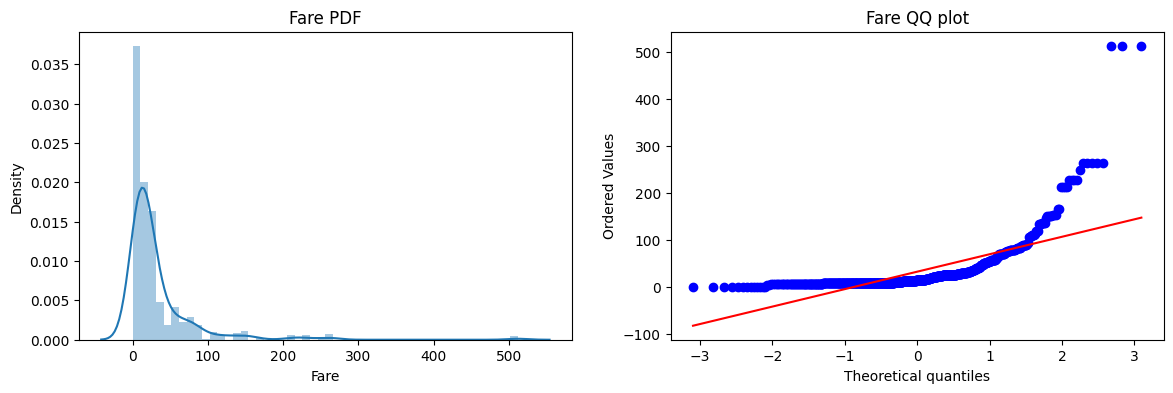

In [30]:
plt.figure(figsize=(14,4))
#1st plot
plt.subplot(121) #1->no.of rows,in this case 2plots in 1row,2->no.of columns(plot1,plot2),1->select plot number 1
sns.distplot(x_train['Fare'])
plt.title('Fare PDF')

#2nd plot
plt.subplot(122)
stats.probplot(x_train['Fare'],dist='norm',plot=plt) #dist='norm'->compare Fare data with a Normal Distribution
plt.title('Fare QQ plot')
plt.show()

In [ ]:
#As 'Fare' is right skewed->Log Transform

In [31]:
#Checking for the 'Age'

C:\Users\alekh\AppData\Local\Temp\ipykernel_14344\2499171691.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


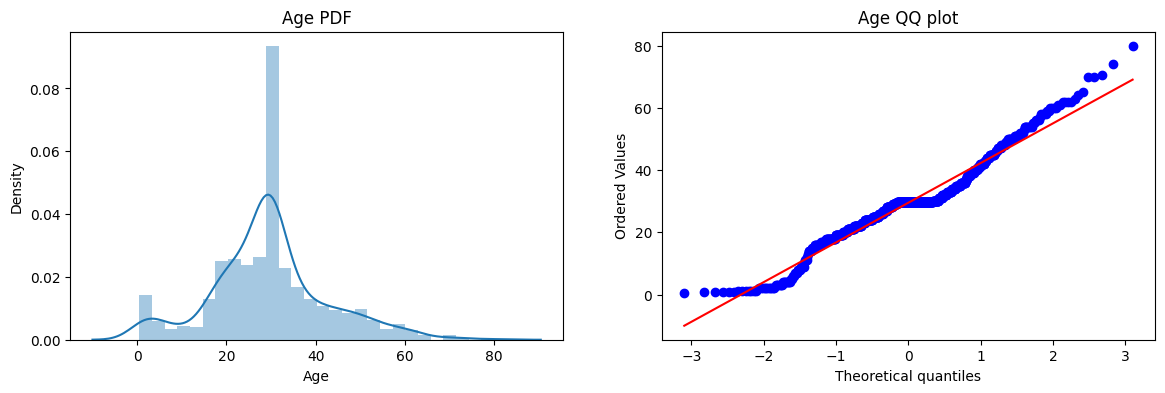

In [32]:
plt.figure(figsize=(14,4))
#1st plot
plt.subplot(121) #1->no.of rows,in this case 2plots in 1row,2->no.of columns(plot1,plot2),1->select plot number 1
sns.distplot(x_train['Age'])
plt.title('Age PDF')

#2nd plot
plt.subplot(122)
stats.probplot(x_train['Age'],dist='norm',plot=plt) #dist='norm'->compare Fare data with a Normal Distribution
plt.title('Age QQ plot')
plt.show()

In [ ]:
#without changing the normalness of the data

In [33]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [35]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred=clf.predict(x_test)
y_pred2=clf2.predict(x_test)

print("Accuracy LR",accuracy_score(y_pred,y_test))
print("Accuracy DT",accuracy_score(y_pred2,y_test))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6871508379888268


In [36]:
#Applying log transform ->changing/improving the normalness

In [37]:
trf=FunctionTransformer(func=np.log1p) #np.log1p->x+1 so for 0 it becomes x=1

In [38]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

In [39]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [40]:
clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred=clf.predict(x_test_transformed)
y_pred2=clf2.predict(x_test_transformed)

print("Accuracy LR",accuracy_score(y_pred,y_test))
print("Accuracy DT",accuracy_score(y_pred2,y_test)) 

Accuracy LR 0.6815642458100558
Accuracy DT 0.6983240223463687


In [41]:
#DT accuracy does not change that much as it is not that dependent on the distribution of data but LR does

In [42]:
#cross validating to check for the improvement 
x_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,x_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,x_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6588639200998753


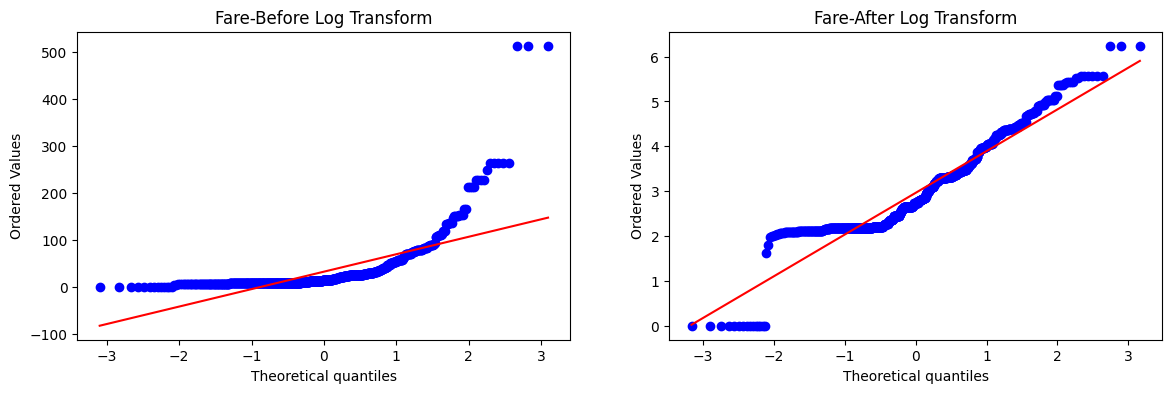

In [44]:
#Comparsion->Fare
plt.figure(figsize=(14,4))
#1st plot #Before Transformation
plt.subplot(121)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('Fare-Before Log Transform')
#2nd plot
plt.subplot(122)
stats.probplot(x_transformed['Fare'],dist='norm',plot=plt)
plt.title('Fare-After Log Transform')
plt.show()

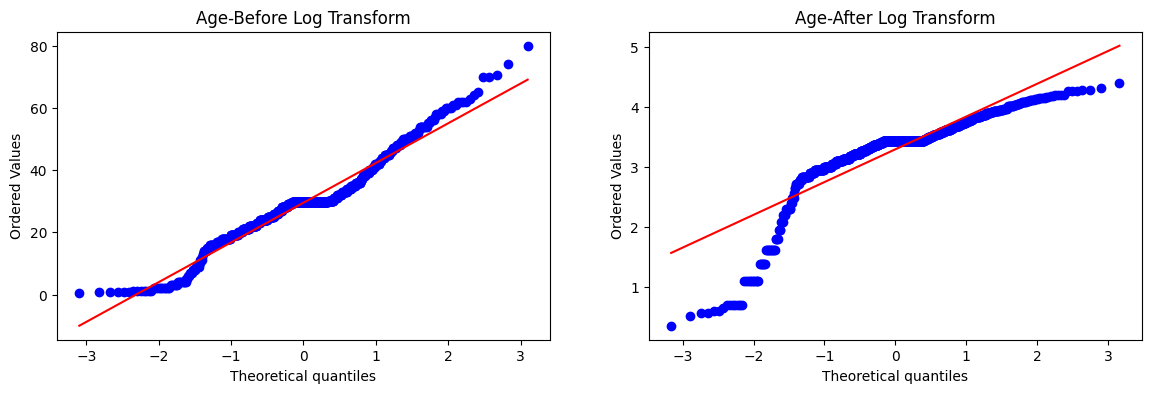

In [46]:
#Comparsion->Age
plt.figure(figsize=(14,4))
#1st plot #Before Transformation
plt.subplot(121)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('Age-Before Log Transform')
#2nd plot
plt.subplot(122)
stats.probplot(x_transformed['Age'],dist='norm',plot=plt)
plt.title('Age-After Log Transform')
plt.show()

In [47]:
#The Normalness gets disturbed on applying it on Age

In [48]:
#Re-applying it on 'Fare' only

In [51]:
def apply_transform(transform):
    x=df.iloc[:,1:]
    y=df.iloc[:,0]
    
    trf=ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    x_trans=trf.fit_transform(x)
    
    clf=LogisticRegression()
    print("LR",np.mean(cross_val_score(clf,x_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))
    
    #1st plot #Before Transformation
    plt.subplot(121)
    stats.probplot(x['Fare'],dist='norm',plot=plt)
    plt.title('Fare-Before Log Transform')
    
    #2nd plot #After Transformation
    plt.subplot(122)
    stats.probplot(x_trans[:,0],dist='norm',plot=plt)
    plt.title('Fare-After Log Transform')
    
    plt.show()
    

LR 0.6589013732833957


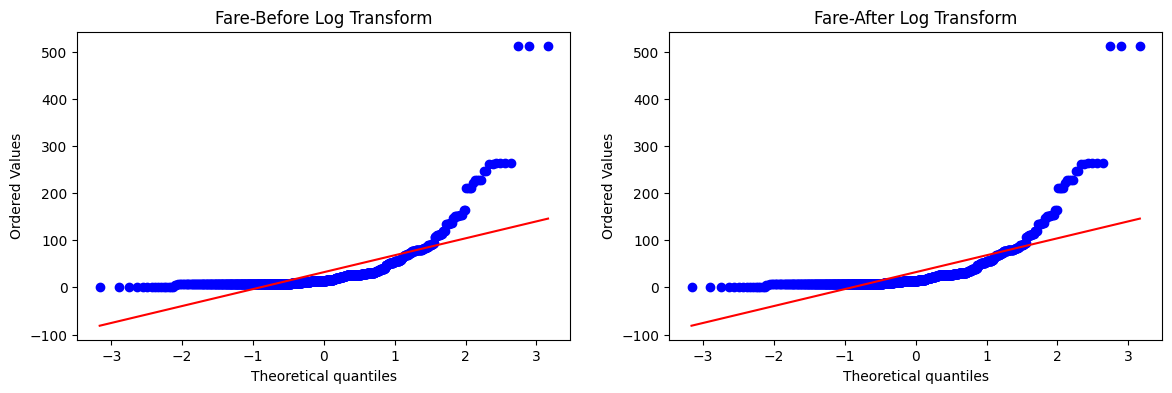

In [52]:
apply_transform(lambda x:x) #Log Transformation

LR 0.6431335830212235


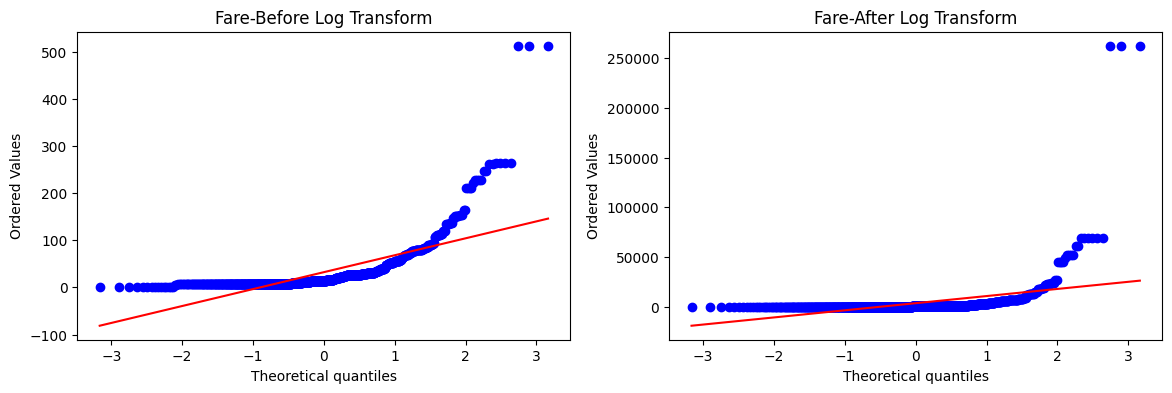

In [53]:
apply_transform(lambda x:x**2) #Square Transformation

LR 0.6589013732833957


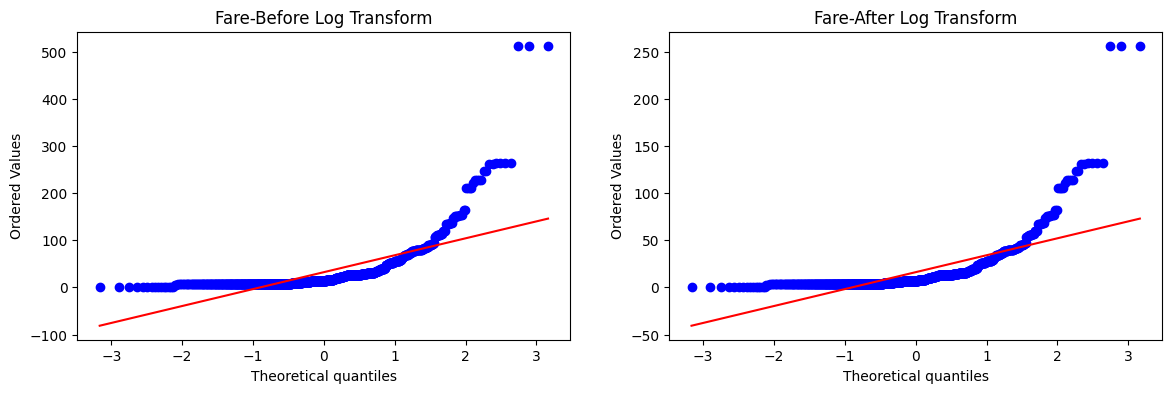

In [55]:
apply_transform(lambda x:x**1/2) #Square root Transformation

# Conclusion

This project demonstrated how appropriate feature transformation can improve the performance and stability of machine learning models, particularly when dealing with skewed numerical features.

### Key Findings

* Applying `np.log1p()` to the heavily right-skewed **Fare** feature reduced its skewness and improved Logistic Regression accuracy from approximately **64.8% to 68.1%**, with cross-validation accuracy of around **67.8%**.

* The **Decision Tree Classifier** showed little meaningful change in performance before and after transformation, supporting the fact that tree-based models do not require normally distributed or similarly scaled features.

* Applying the log transformation to all numerical features negatively affected the distribution of **Age**, which was already relatively well behaved. Using **Scikit-Learn's `ColumnTransformer`** to transform only the `Fare` feature preserved the original structure of other features and provided more stable results.

* Comparison using distribution plots and Q-Q plots showed that logarithmic transformation effectively reduced the extreme right-skewness of **Fare**, whereas a square transformation amplified the skewness. This highlights the importance of selecting a transformation according to the underlying distribution of the feature.

### Overall Takeaway

> **Feature transformation should not be applied blindly to every feature. The appropriate transformation depends on the feature's distribution and the requirements of the machine learning algorithm.**

In this project, **log transformation of the right-skewed Fare feature was particularly beneficial for Logistic Regression**, while the Decision Tree remained relatively unaffected. This demonstrates why understanding both the **data distribution** and the **behavior of the chosen ML algorithm** is essential during feature engineering.
